# Generating data — from the smallest graph to a confounded world

`prior_generator` draws **synthetic marketing worlds** as structural causal
models: a DAG over media channels `C`, observed controls `Z`, hidden demand
factors `D`, a baseline `B`, and sales `Y`, with an exact decomposition of
`Y` into its causes.

This notebook builds up one knob at a time:

| section | what it adds |
| --- | --- |
| 1 | the minimal world: one channel, nothing else |
| 2 | what a world contains — observables versus truth |
| 3 | the parameter groups, and where each one enters |
| 4 | media response: adstock and saturation families |
| 5 | channel texture — what makes spend sweep its response curve |
| 6 | outcome-side noise, and the one ratio that decides recoverability |
| 7 | controls and interactions: `Z→Y`, `Z→C`, `C→C` |
| 8 | hidden confounding: `D→C` with `D→Y` |
| 9 | a corpus of many worlds, validated |
| 10 | how large is everything? outcome distributions across worlds |

> Every cell below is executed when the docs are built — the outputs and
> figures you see are real.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')      # hide harmless tqdm/ipywidgets notices

import os
import tempfile

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

import prior_generator as pg
from prior_generator import viz

print('prior-generator', pg.__version__)

prior-generator 0.0.1


## 1 · The minimal world

Every world is drawn from an `SCMPrior`. Build one with `make_scm_prior`:
the three sizes are **required** because they pin the tensor layout, and
`edge_budget` says how many arrows of each type to place.

The smallest useful graph is one channel affecting sales and nothing else.
`edge_budget={'cy': (1, 1)}` means *exactly one* `C→Y` arrow; every other
edge type is pinned to zero, so there are no controls, no confounding, and
no channel interactions.

The eight edge types are `cy` (channel→sales), `zy` (control→sales),
`dy` (demand→sales), `dc` (demand→channel), `dz` (demand→control),
`zc` (control→channel), `cc` (channel→channel), and `zz`
(control→control).

In [2]:
MINIMAL_EDGES = {
    'cy': (1, 1),   # exactly one channel -> sales arrow
    'zy': (0, 0), 'dy': (0, 0), 'dc': (0, 0), 'dz': (0, 0),
    'zc': (0, 0), 'cc': (0, 0), 'zz': (0, 0),
}

minimal = pg.make_scm_prior(
    n_treatments=1,       # media channels (the interventions)
    n_covariates=1,       # observed controls
    n_latent=1,           # hidden demand factors
    n_time_steps=104,     # weeks
    edge_budget=MINIMAL_EDGES,
    n_cells=2, draws_per_cell=1, seed=20260728,
)

world = pg.sample_scm(minimal, seed=1, name='minimal')
print(f'n_time_steps={world.n_time_steps}  n_treatments={world.n_treatments}  '
      f'n_covariates={world.n_covariates}  n_latent={world.n_latent}')
print('edges present:', {k: int(np.asarray(v).sum()) for k, v in world.g.items()})

n_time_steps=104  n_treatments=1  n_covariates=1  n_latent=1
edges present: {'g_cy': 1, 'g_dc': 0, 'g_dz': 0, 'g_db': 0, 'g_zb': 0, 'g_zc': 0, 'g_cc': 0, 'g_zz': 0}


`sample_scm` returns one accepted world. `n_time_steps` is the reported
horizon; the graph is simulated over `n_time_steps + adstock_burn_in` weeks
and sliced, so the first reported week already has real carryover history
behind it.

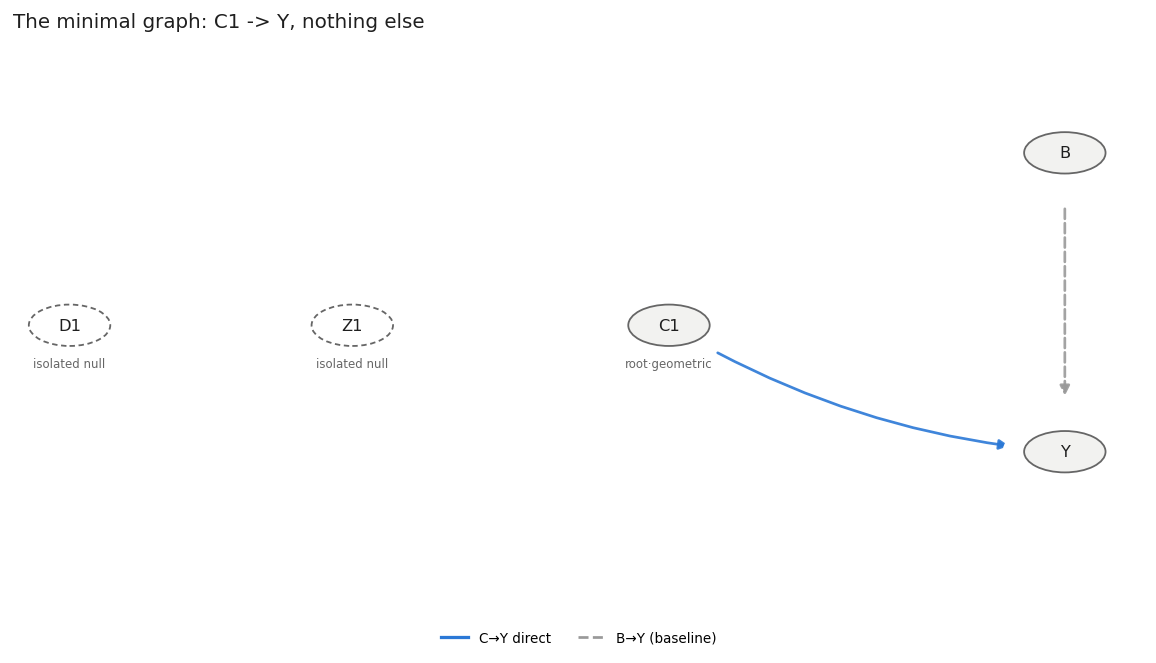

In [3]:
def show(plot_fn, world, title):
    """Render one of the viz helpers inline."""
    path = os.path.join(tempfile.mkdtemp(), 'fig.png')
    plot_fn(world, path, title)
    display(Image(filename=path))

show(viz.plot_dag, world, 'The minimal graph: C1 -> Y, nothing else')

## 2 · What a world contains

`world.data` holds both what a model may see and what only the generator
knows. Keeping the two apart is the whole point of the package.

**Model-facing** (`channels`, `controls`, `sales`) is what an MMM gets.
Everything else is **truth**, for scoring only: `contributions_observed`
(each channel's true weekly effect on the realised spend path),
`contributions` (the same response on the *counterfactual* spend with all
upstream arrows cut), `baseline`, `demand`, and the per-source splits.

In [4]:
MODEL_FACING = ('channels', 'controls', 'sales')
for name, array in sorted(world.data.items()):
    array = np.asarray(array)
    if array.ndim == 0 or array.size == 0:
        continue
    tag = 'observable' if name in MODEL_FACING else 'truth'
    print(f'{name:28s} {str(array.shape):12s} {tag}')

baseline                     (104,)       truth
baseline_intrinsic           (104,)       truth
channel_shock_mask           (104, 1)     truth
channel_shock_mask_full      (112, 1)     truth
channels                     (104, 1)     observable
channels_base                (104, 1)     truth
confounder_contribution      (104, 1)     truth
contributions                (104, 1)     truth
contributions_observed       (104, 1)     truth
control_contribution         (104, 1)     truth
controls                     (104, 1)     observable
demand                       (104, 1)     truth
indirect_effects             (104,)       truth
indirect_effects_by_source   (104, 3)     truth
sales                        (104,)       observable
sales_noise                  (104,)       truth
saturation_scale             (1,)         truth


The decomposition is **exact**, not approximate. Sales equals the sum of its
causes to floating-point error, and `identity_error()` proves it on every
world:

```
sales = baseline_intrinsic             (the intercept B)
      + sales_noise                    (iid observation noise)
      + Σ confounder_contribution      (D → Y)
      + Σ control_contribution         (Z → Y)
      + Σ contributions                (direct media effect)
      + Σ indirect_effects_by_source   (media moved by upstream causes)
```

In [5]:
print('max |Σ causes − sales| =', f'{world.identity_error():.2e}')
assert world.identity_error() < 1e-9

max |Σ causes − sales| = 8.88e-16


## 3 · The parameters

`world.params` is the realised draw. It groups into five families, and the
`SCMPrior` field that governs each one is named alongside:

| group | parameters | prior field |
| --- | --- | --- |
| **edge coefficients** | `beta` (`C→Y`), `rho_zy` (`Z→Y`), `delta_dy` (`D→Y`), `w_dc` (`D→C`), `u_dz` (`D→Z`), `v_zc` (`Z→C`), `alpha_cc` (`C→C`), `gamma_zz` (`Z→Z`) | `*_coeff_range`, `beta_additive_range` |
| **media response** | `adstock_family`, `adstock_alpha`, `weibull_*`, `sat_family`, `mm_kappa_mult`, `hill_*`, `logistic_lam`, `tanh_c`, `root_alpha` | `*_family_probs`, `adstock_alpha_range` |
| **node processes** | `rw_d`, `rw_z`, `rw_c`, `rw_b` random walks, `rw_y` iid noise | `rw_*_range`, `rw_*_sigma`, `rw_smoothness_*` |
| **channel texture** | `hf_sigma`, `pulse_amp`, `pulse_prob` | `channel_hf_sigma_range`, `channel_pulse_*_range` |
| **control texture** | `control_hf_sigma`, `control_pulse_amp`, `control_pulse_prob` (pulse centred) | `control_hf_sigma_range`, `control_pulse_*_range` |
| **anchors** | `channel_level`, `saturation_scale` | derived from the above |

`world.equations` renders the executed structural assignments for this exact
world, and `world.equation_parameters` gives the realised numbers behind
them — so a world is auditable without reading the source.

In [6]:
for node in ('C1', 'B', 'Y'):
    print(f'{node}:  {world.equations[node]}\n')

C1:  use_hf[0]=True; use_pulse[0]=True; own_C1_full = RW_full(eps_c_eff[:, 0], rw_c[0]) + hf_sigma[0] * eps_c_hf[:, 0] + pulse_amp[0] * eps_c_pulse[:, 0]; C1_unshocked_full = softplus(own_C1_full); C1_full = softplus(own_C1_full); C1 = C1_full[burn_in:]

B:  B_full = RW_full(eps_b, rw_b[0]); B = B_full[burn_in:]

Y:  non_media_full = B_full; sales_noise = rw_y[0].std * eps_y[burn_in:]; baseline = non_media_full[burn_in:] + sales_noise; baseline_intrinsic = B; Y (sales) = baseline + sum_k contributions_observed[:, k]. Sales is never clipped: the observation noise is symmetric, so a clamp here would censor the OBSERVATION; the acceptance filter enforces non-negative sales instead.



In [7]:
def fmt(group, places=3):
    """Readable one-line view of a walk / noise parameter group."""
    out = {}
    for key, value in group.items():
        array = np.asarray(value)
        out[key] = (np.round(array, places) if array.dtype.kind in 'fc' else array).tolist()
    return out

params = world.params
print('beta  (C->Y effect):', np.round(np.asarray(params['beta']), 3))
print('rw_c  (spend walk) :', fmt(params['rw_c']))
print('rw_b  (baseline walk):', fmt(params['rw_b']))
print('rw_y  (iid sales noise):', fmt(params['rw_y'], 4))

beta  (C->Y effect): [0.706]
rw_c  (spend walk) : {'mean': [1.412], 'std': [0.696], 'positive_only': True, 'smoothness': [0.658], 'rw_smoothness_max_weeks': 26}
rw_b  (baseline walk): {'mean': [5.9], 'std': [0.064], 'positive_only': False, 'smoothness': [0.394], 'rw_smoothness_max_weeks': 26}
rw_y  (iid sales noise): {'mean': [0.0], 'std': [0.0143], 'positive_only': False}


In [8]:
# Only the shape params this world's own families consume carry meaning.
from prior_generator.sampler import ADSTOCK_FAMILY_KEYS, SATURATION_FAMILY_KEYS
from prior_generator.world_model import (
    ADSTOCK_FAMILY_PARAM_NAMES,
    SATURATION_FAMILY_PARAM_NAMES,
)

adstock = ADSTOCK_FAMILY_KEYS[int(params['adstock_family'][0])]
saturation = SATURATION_FAMILY_KEYS[int(params['sat_family'][0])]
print(f'C1 drew adstock={adstock!r}, saturation={saturation!r}')
for name in ADSTOCK_FAMILY_PARAM_NAMES[adstock] + SATURATION_FAMILY_PARAM_NAMES[saturation]:
    print(f'  {name:16s}', np.round(np.asarray(params[name]), 3))
print(f"  {'saturation_scale':16s}", np.round(np.asarray(world.data['saturation_scale']), 3))

C1 drew adstock='geometric', saturation='root'
  adstock_alpha    [0.591]
  root_alpha       [0.801]
  saturation_scale [1.982]


Note `rw_y` has a `std` but **no smoothness**: the outcome's exogenous term
is iid observation noise. Every other node carries a smoothed random walk,
whose `smoothness` sets its moving-average width in weeks. `B` is therefore
the only latent *trend* in the outcome, which is what makes the baseline and
the noise separately identified.

## 4 · Media response: adstock × saturation

Each channel's effect is `beta * saturation(adstock(spend))`. Both transforms
come from `pymc-marketing`, so a standard MMM can represent them exactly.
Families are drawn per channel from `adstock_family_probs` and
`saturation_family_probs`; pin them to a single name for a controlled study.

Saturation is **κ-relative**: the knee sits at
`kappa_mult × saturation_scale`, where `saturation_scale` is the channel's
expected spend level computed from parameters alone. So a channel operates
near its own knee whatever its spend units are.

In [9]:
print('adstock families   :', ADSTOCK_FAMILY_KEYS)
print('saturation families:', SATURATION_FAMILY_KEYS)

def pin(adstock, saturation):
    """Family probability dicts that select exactly one family each."""
    return {
        'adstock_family_probs': {**dict.fromkeys(ADSTOCK_FAMILY_KEYS, 0.0), adstock: 1.0},
        'saturation_family_probs': {
            **dict.fromkeys(SATURATION_FAMILY_KEYS, 0.0), saturation: 1.0
        },
    }

print('\nper-family shape params:')
for family, names in SATURATION_FAMILY_PARAM_NAMES.items():
    print(f'  {family:18s} {names or "(none)"}')

adstock families   : ('none', 'geometric', 'weibull')
saturation families: ('linear', 'hill', 'logistic', 'michaelis_menten', 'tanh', 'root')

per-family shape params:
  linear             (none)
  hill               ('hill_slope', 'hill_kappa_mult')
  logistic           ('logistic_lam',)
  michaelis_menten   ('mm_kappa_mult',)
  tanh               ('tanh_c',)
  root               ('root_alpha',)


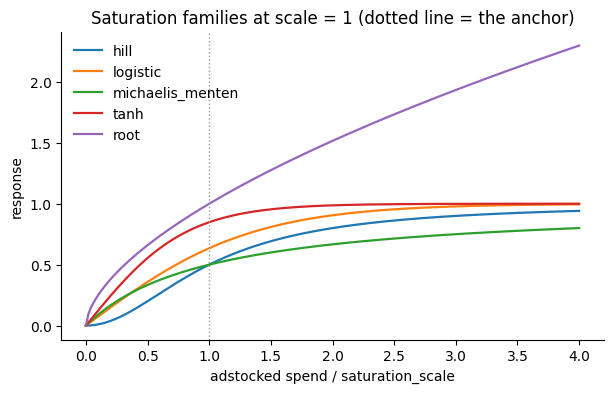

In [10]:
# The response curve each family implies, on the same adstocked spend.
import pytensor.tensor as pt
from prior_generator import mechanisms

grid = np.linspace(0.0, 4.0, 200)
shape_args = {
    'hill': dict(slope=2.0, kappa_mult=1.0),
    'logistic': dict(lam=1.5),
    'michaelis_menten': dict(kappa_mult=1.0),
    'tanh': dict(c=0.8),
    'root': dict(alpha=0.6),
}
fig, ax = plt.subplots(figsize=(7, 4))
for name, kwargs in shape_args.items():
    curve = mechanisms.SATURATION_FAMILIES[name](
        pt.as_tensor_variable(grid), pt.as_tensor_variable(1.0), **kwargs
    ).eval()
    ax.plot(grid, curve, lw=1.6, label=name)
ax.axvline(1.0, color='0.6', ls=':', lw=1)
ax.set(xlabel='adstocked spend / saturation_scale', ylabel='response',
       title='Saturation families at scale = 1 (dotted line = the anchor)')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.show()

## 5 · Channel texture

A saturating, carryover-smoothed response can only be *identified* if spend
actually moves across the curve. Three knobs drive that, all relative to the
channel's own level so they are scale-free:

- `rw_channel_std_range` — the slow walk in spend,
- `channel_hf_sigma_range` — iid weekly execution noise,
- `channel_pulse_prob_range` / `channel_pulse_amp_range` — campaign bursts.

Compare a deliberately smooth channel against the shipped default.

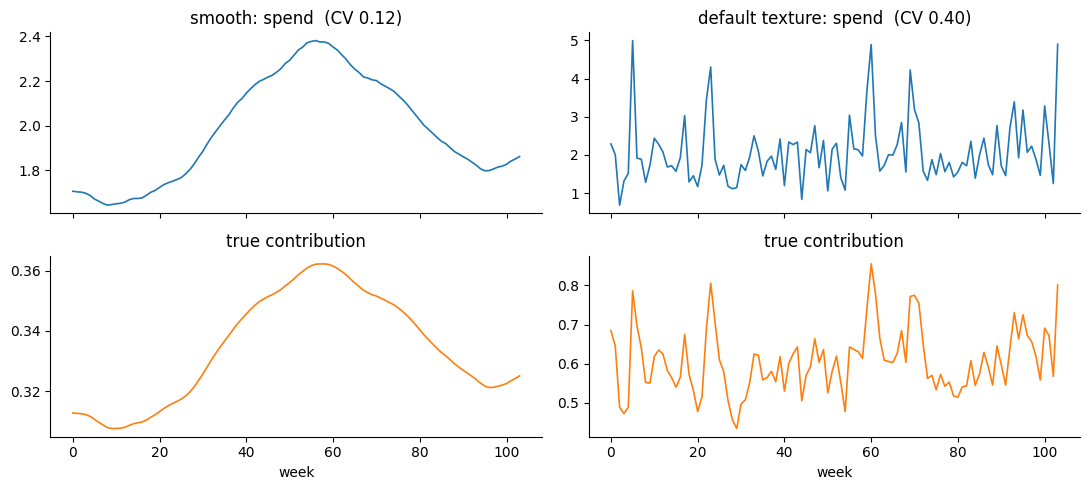

In [11]:
def one_channel(label, **overrides):
    cfg = pg.make_scm_prior(
        n_treatments=1, n_covariates=1, n_latent=1, n_time_steps=104,
        edge_budget=MINIMAL_EDGES, n_cells=2, draws_per_cell=1, seed=20260728,
        **pin('geometric', 'michaelis_menten'), **overrides,
    )
    return pg.sample_scm(cfg, seed=4, name=label)

smooth = one_channel('smooth', channel_hf_sigma_range=(0.0, 0.0),
                     channel_pulse_prob_range=(0.0, 0.0),
                     rw_channel_std_range=(0.15, 0.2))
textured = one_channel('textured')   # shipped default texture

fig, axes = plt.subplots(2, 2, figsize=(11, 5), sharex=True)
for col, (w, label) in enumerate(((smooth, 'smooth'), (textured, 'default texture'))):
    weeks = np.arange(w.n_time_steps)
    spend = w.data['channels'][:, 0]
    axes[0, col].plot(weeks, spend, lw=1.2, color='C0')
    axes[0, col].set_title(f'{label}: spend  (CV {spend.std() / spend.mean():.2f})')
    axes[1, col].plot(weeks, w.data['contributions_observed'][:, 0], lw=1.2, color='C1')
    axes[1, col].set(xlabel='week')
    axes[1, col].set_title('true contribution')
for ax in axes.ravel():
    ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

The smooth channel's contribution is nearly a flat line: there is almost no
variation for a model to attribute. The textured one sweeps its curve, which
is what makes `adstock_alpha` and `mm_kappa_mult` estimable.

## 6 · Outcome-side noise, and the ratio that decides recoverability

Two terms sit between the media effect and observed sales: the baseline walk
`RW_B` (a latent trend) and `RW_Y` (iid observation noise). Their amplitudes
are drawn *relative to the media amplitude*
`sqrt(Σ (g_cy · beta)²)` — a function of parameters alone — so the
signal-to-noise ratio is a declared axis rather than an accident of units:

- `rw_baseline_std_range` — the latent trend, in media-amplitude units,
- `rw_sales_std_range` — the observation noise, same units,
- `outcome_std_mode='absolute'` — opt out and set the old absolute scales.

The quantity that predicts whether *anything* can recover a world is

$$\text{ratio} = \frac{\mathrm{sd}(\text{baseline trend} + \text{latent baseline})}{\mathrm{sd}(\text{total media contribution})}$$

Real weekly MMM data sits near 0.2–0.7. Let's measure it across the default
prior.

In [12]:
def outcome_ratio(w):
    """sd(unrepresentable outcome terms) / sd(total media contribution)."""
    start = w.cfg.l_max
    residual = (np.asarray(w.data['baseline_intrinsic'])
                + np.asarray(w.data['confounder_contribution']).sum(1))[start:]
    media = np.asarray(w.data['contributions_observed']).sum(1)[start:]
    return float(np.std(residual) / np.std(media))

# Measure the whole prior at once: a corpus is far cheaper than one
# sample_scm call per world.
ratio_cfg = pg.make_scm_prior(
    n_treatments=1, n_covariates=1, n_latent=1, n_time_steps=104,
    edge_budget=MINIMAL_EDGES, n_cells=12, draws_per_cell=3, seed=20260728,
    **pin('geometric', 'michaelis_menten'),
)
ratio_corpus = pg.sample_prior_predictive(ratio_cfg)
window = slice(ratio_cfg.l_max, None)
residual = (ratio_corpus['baseline_intrinsic']
            + ratio_corpus['confounder_contribution'].sum(-1))[:, window]
media = ratio_corpus['contributions_raw'].sum(-1)[:, window]
ratios = residual.std(axis=1) / media.std(axis=1)
q5, q50, q95 = np.quantile(ratios, [0.05, 0.5, 0.95])
print(f'residual/media ratio over {len(ratios)} worlds: '
      f'p5 {q5:.2f}   median {q50:.2f}   p95 {q95:.2f}')
print('real weekly MMM data sits near 0.2-0.7, so the prior is centred on it')
print('and still keeps a hard tail on purpose.')

residual/media ratio over 36 worlds: p5 0.06   median 0.29   p95 1.75
real weekly MMM data sits near 0.2-0.7, so the prior is centred on it
and still keeps a hard tail on purpose.


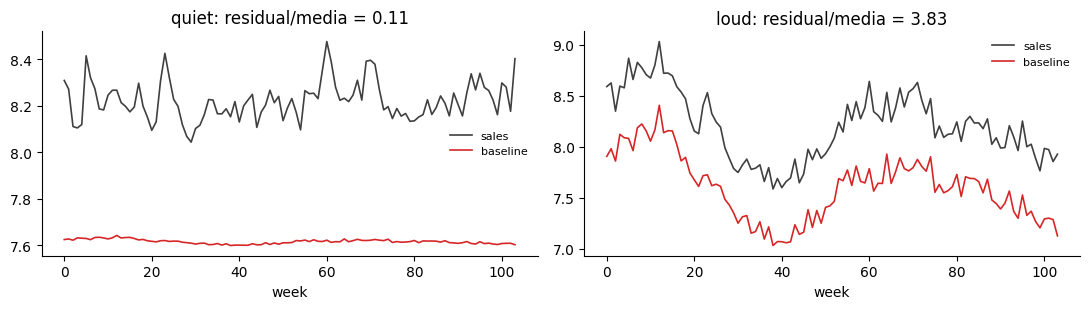

In [13]:
# Turn the knob explicitly: a quiet world and a loud one, same graph.
quiet = one_channel('quiet', rw_baseline_std_range=(0.005, 0.010),
                    rw_sales_std_range=(0.002, 0.004))
loud = one_channel('loud', rw_baseline_std_range=(0.20, 0.30),
                   rw_sales_std_range=(0.05, 0.08))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=False)
for ax, w in zip(axes, (quiet, loud)):
    weeks = np.arange(w.n_time_steps)
    ax.plot(weeks, w.data['sales'], lw=1.2, color='0.25', label='sales')
    ax.plot(weeks, w.data['baseline'], lw=1.2, color='C3', label='baseline')
    ax.set(xlabel='week', title=f'{w.name}: residual/media = {outcome_ratio(w):.2f}')
    ax.legend(frameon=False, fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

## 7 · Controls and interactions

Now grow the graph. Three edge types make the world harder in *structurally*
different ways:

- **`zy`** — a control affects sales directly. A regression that
  includes the control handles this.
- **`zc`** — a control also moves spend. Now the control is a confounder of
  the media effect, but an **observed** one, so adjusting for it is licensed.
- **`cc`** — one channel drives another. The direct effect and the total
  effect now differ, which is why the package reports both
  `contributions` (direct) and `contributions_observed` (realised).

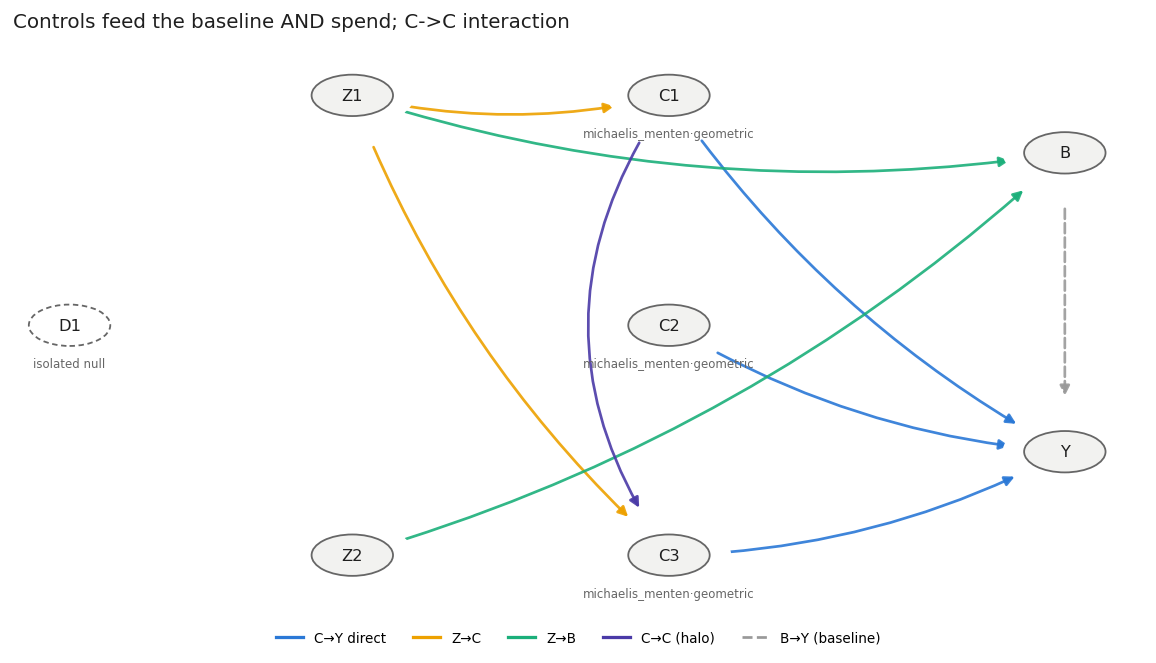

In [14]:
interacting = pg.make_scm_prior(
    n_treatments=3, n_covariates=2, n_latent=1, n_time_steps=104,
    n_treatments_active_range=(3, 3), n_covariates_active_range=(2, 2),
    n_latent_active_range=(1, 1),
    edge_budget={'cy': (3, 3), 'zy': (2, 2), 'zc': (2, 2), 'cc': (1, 1),
                 'dy': (0, 0), 'dc': (0, 0), 'dz': (0, 0), 'zz': (0, 0)},
    n_cells=2, draws_per_cell=1, seed=20260728,
    **pin('geometric', 'michaelis_menten'),
)
mid = pg.sample_scm(interacting, seed=2, name='interacting')
show(viz.plot_dag, mid, 'Controls affect sales AND spend; C->C interaction')

In [15]:
indirect = np.asarray(mid.data['indirect_effects_by_source'])
start = mid.cfg.l_max
labels = ('C->C', 'Z->C', 'D->C')
print('cumulative effect routed through upstream causes, by source:')
for label, column in zip(labels, indirect[start:].T):
    print(f'  {label:6s} {column.sum():+10.3f}')
print('\ntotal indirect  ', f"{np.asarray(mid.data['indirect_effects'])[start:].sum():+10.3f}")
print('total direct    ',
      f"{np.asarray(mid.data['contributions'])[start:].sum():+10.3f}")

cumulative effect routed through upstream causes, by source:
  C->C       +0.625
  Z->C       -0.258
  D->C       +0.000

total indirect       +0.367
total direct       +116.903


The 3-way split is reported under a **fixed sequential zeroing order**
(`cc → zc → dc`). The total is order-free and is a genuine estimand; the
split is a convention, so do not score a model against it as though it were
identified.

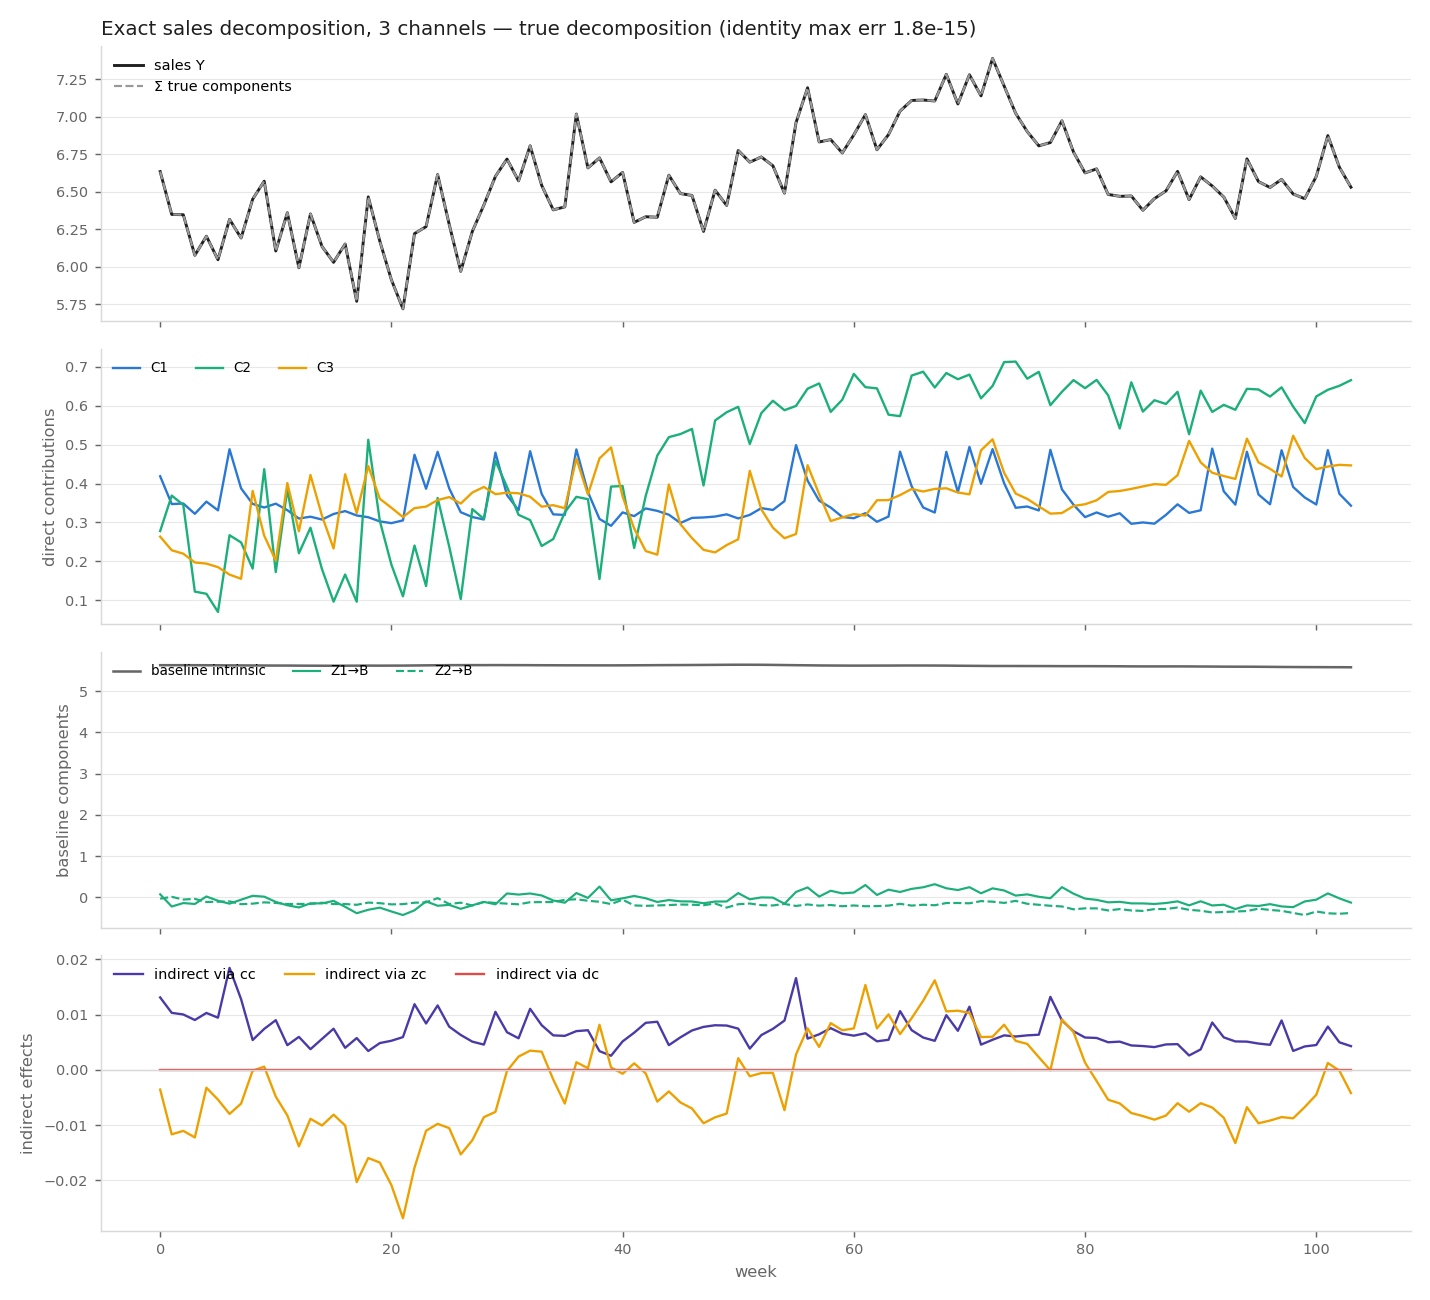

In [16]:
show(viz.plot_decomposition, mid, 'Exact sales decomposition, 3 channels')

## 8 · Hidden confounding

The hard case. A latent demand factor `D` drives **both** spend (`dc`) and
sales (`dy`). Now there is an unobserved common cause of treatment and
outcome: a back-door path `C ← D → Y` that no regression on observables
can close. Causal sufficiency fails.

`D` is in `world.data['demand']` for scoring, and it is **never** a
model-facing column.

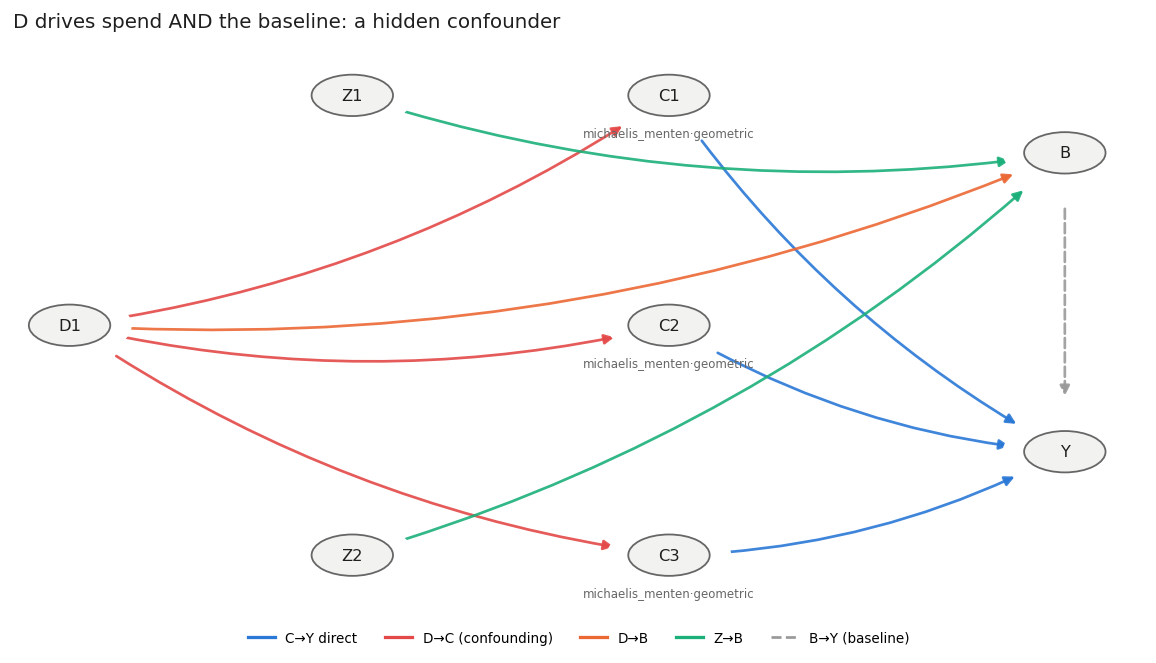

In [17]:
confounded_cfg = pg.make_scm_prior(
    n_treatments=3, n_covariates=2, n_latent=1, n_time_steps=104,
    n_treatments_active_range=(3, 3), n_covariates_active_range=(2, 2),
    n_latent_active_range=(1, 1),
    edge_budget={'cy': (3, 3), 'zy': (2, 2), 'dc': (3, 3), 'dy': (1, 1),
                 'dz': (0, 0), 'zc': (0, 0), 'cc': (0, 0), 'zz': (0, 0)},
    dc_coeff_range=(0.6, 1.2),   # turn the confounding up so it is visible
    dy_coeff_range=(0.4, 0.8),
    n_cells=2, draws_per_cell=1, seed=20260728,
    **pin('geometric', 'michaelis_menten'),
)
confounded = pg.sample_scm(confounded_cfg, seed=2, name='confounded')
show(viz.plot_dag, confounded, 'D drives spend AND sales: a hidden confounder')

In [18]:
start = confounded.cfg.l_max
demand = np.asarray(confounded.data['demand'])[start:, 0]
spend = np.asarray(confounded.data['channels'])[start:]
base = np.asarray(confounded.data['channels_base'])[start:]   # spend with D -> C cut
baseline = np.asarray(confounded.data['baseline'])[start:]

print('D -> C loadings (w_dc)    :', np.round(np.asarray(confounded.params['w_dc']), 3))
print('D -> Y loading  (delta_dy):', np.round(np.asarray(confounded.params['delta_dy']), 3))
print()
print('corr(D, baseline)                :',
      round(float(np.corrcoef(demand, baseline)[0, 1]), 3))
print('corr(D, D-driven part of spend)  :',
      np.round([np.corrcoef(demand, (spend - base)[:, k])[0, 1]
                for k in range(confounded.n_treatments)], 3))
print('share of each channel sd from D  :',
      np.round((spend - base).std(0) / spend.std(0), 3))
print()
print('corr(D, REALISED spend)          :',
      np.round([np.corrcoef(demand, spend[:, k])[0, 1]
                for k in range(confounded.n_treatments)], 3))

D -> C loadings (w_dc)    : [[1.027 0.856 0.704]]
D -> B loading  (delta_db): [0.69]

corr(D, baseline)                : 0.974
corr(D, D-driven part of spend)  : [0.993 0.92  0.994]
share of each channel sd from D  : [0.455 0.147 0.145]

corr(D, REALISED spend)          : [0.469 0.316 0.08 ]


Read those last two blocks together — the lesson is why you cannot detect
confounding from a correlation.

`channels_base` is the counterfactual spend path with every incoming arrow
cut, so `channels - channels_base` is *exactly* the part of spend that `D`
caused. Its correlation with `D` is ~1.0 and it carries a large share of each
channel's variation: the confounding is structurally strong and unambiguous.

Yet `corr(D, realised spend)` is all over the place and can even come out
**negative**, because the channel's own independent walk dominates its level
and two smooth series of 100 weeks have a large sample correlation by chance.
A naive regression of sales on spend absorbs the `D`-driven part into `beta`,
and no diagnostic on the observables reveals it.

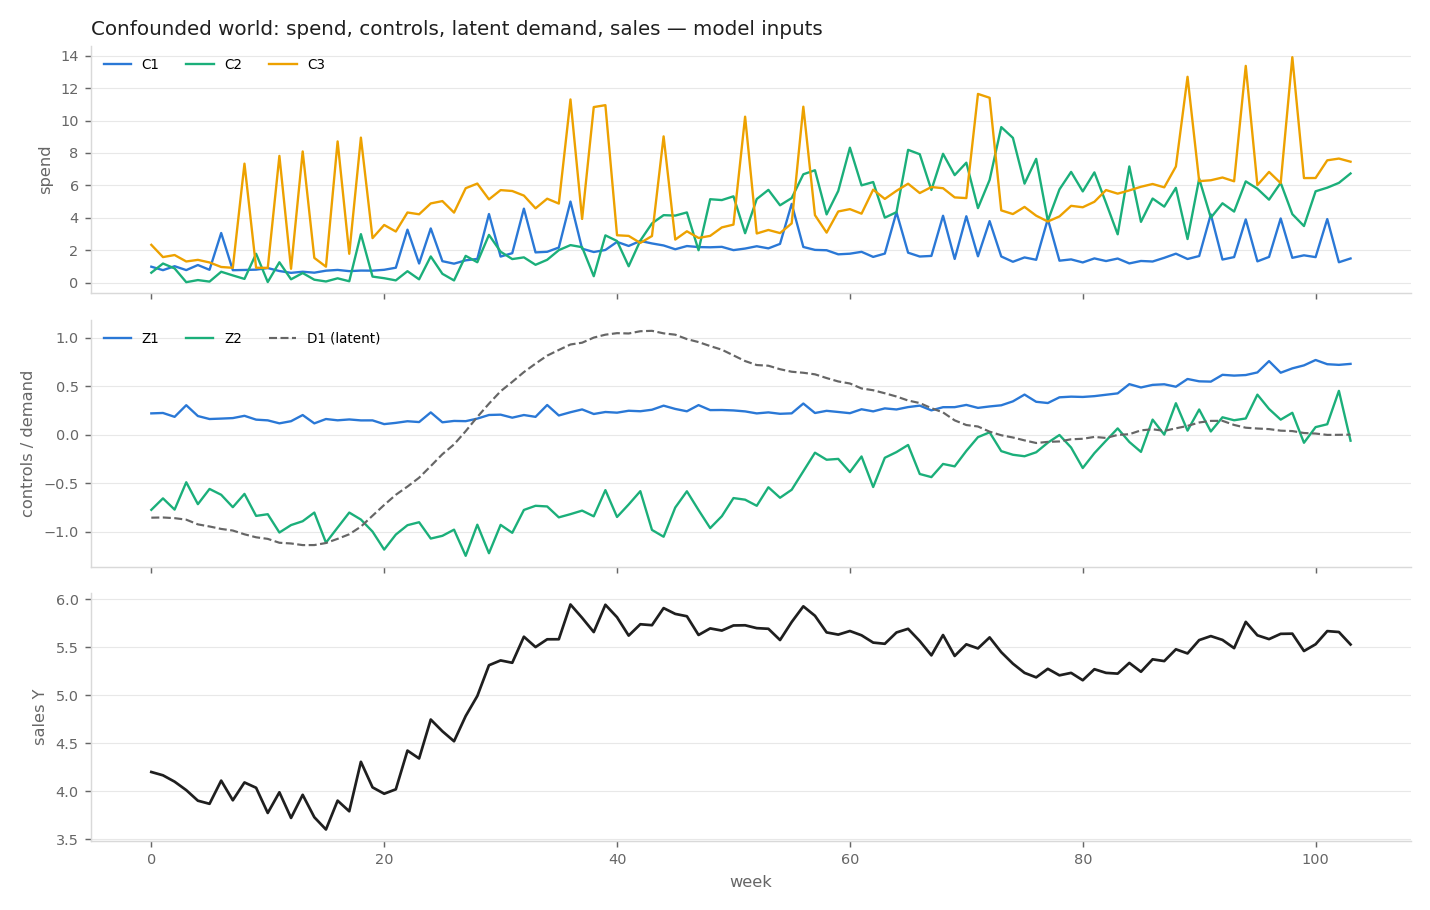

In [19]:
show(viz.plot_timeseries, confounded, 'Confounded world: spend, controls, latent demand, sales')

A second lever is available for the same story without an extra node:
`confounding_strength_range` draws a per-world `rho` that mixes the baseline
innovation into every channel innovation. That makes the model
*semi-Markovian* — an unobserved common cause with no node of its own — so
back-door adjustment on observables is not licensed either. Every
"the graph satisfies the adjustment criterion" claim in these docs assumes
`rho = 0`.

In [20]:
rho_cfg = pg.make_scm_prior(
    n_treatments=2, n_covariates=1, n_latent=1, n_time_steps=104,
    n_treatments_active_range=(2, 2), n_covariates_active_range=(1, 1),
    n_latent_active_range=(1, 1),
    edge_budget={'cy': (2, 2), 'zy': (1, 1), 'dy': (0, 0), 'dc': (0, 0),
                 'dz': (0, 0), 'zc': (0, 0), 'cc': (0, 0), 'zz': (0, 0)},
    confounding_strength_range=(0.6, 0.9),
    n_cells=2, draws_per_cell=1, seed=20260728,
    **pin('geometric', 'michaelis_menten'),
)
rho_world = pg.sample_scm(rho_cfg, seed=3, name='rho')
print('drawn confounding strength rho =',
      f"{float(rho_world.data['confounding_strength']):.3f}")
print('graph has no D edges:',
      not any(np.asarray(rho_world.g[k]).any() for k in ('g_dc', 'g_dy', 'g_dz')))

drawn confounding strength rho = 0.866
graph has no D edges: True


## 9 · A corpus of many worlds

`sample_prior_predictive` draws many worlds at once and returns flat numpy
arrays — a corpus. Inactive slots are zero-padded and masked, so a consumer
sees one fixed layout whether a task's `n_treatments_active` is 2 or 8.

Widening the `*_active_range` arguments and dropping the `edge_budget` pins
gives graph-size and structure variety across tasks.

In [21]:
corpus_cfg = pg.make_scm_prior(
    n_treatments=5, n_covariates=3, n_latent=2, n_time_steps=104,
    n_treatments_active_range=(2, 5),      # graph size varies per task
    n_covariates_active_range=(1, 3),
    n_latent_active_range=(1, 2),
    edge_budget={'cy': (2, 5), 'zy': (1, 3), 'dc': (0, 4), 'dy': (0, 2),
                 'zc': (0, 3), 'cc': (0, 2), 'dz': (0, 2), 'zz': (0, 1)},
    n_cells=6, draws_per_cell=2, seed=20260728,
)
corpus = pg.sample_prior_predictive(corpus_cfg)
print('tasks:', len(corpus['sales_raw']),
      '| elapsed:', f"{corpus['diagnostics']['timing']['elapsed_s']:.1f}s")
print('\nkey                          shape')
for key in ('spend_raw', 'controls', 'sales_raw', 'contributions_raw',
            'treatment_active_mask', 'g'):
    print(f'{key:28s} {np.asarray(corpus[key]).shape}')

tasks: 12 | elapsed: 10.8s

key                          shape
spend_raw                    (12, 104, 5)
controls                     (12, 104, 3)
sales_raw                    (12, 104)
contributions_raw            (12, 104, 5)
treatment_active_mask        (12, 5)
g                            (12, 67)


In [22]:
errors = pg.DataGenerator.validate_corpus(corpus)
print('validation errors:', errors or 'none')
assert errors == []

print('\nactive counts per task (treatments / covariates / latent):')
for i in range(len(corpus['n_treatments_active'])):
    print(f"  task {i:2d}  {corpus['n_treatments_active'][i]} / "
          f"{corpus['n_covariates_active'][i]} / {corpus['n_latent_active'][i]}")

validation errors: none

active counts per task (treatments / covariates / latent):
  task  0  4 / 2 / 2
  task  1  4 / 2 / 2
  task  2  4 / 2 / 2
  task  3  4 / 2 / 2
  task  4  4 / 1 / 2
  task  5  4 / 1 / 2
  task  6  2 / 1 / 1
  task  7  2 / 1 / 1
  task  8  3 / 3 / 2
  task  9  3 / 3 / 2
  task 10  5 / 1 / 1
  task 11  5 / 1 / 1


Every corpus carries a self-describing contract in
`diagnostics['signal']`, including the outcome-noise semantics a consumer
must agree with before scoring anything.

In [23]:
signal = corpus['diagnostics']['signal']
print('outcome-noise contract:', signal['outcome_noise_semantics'],
      'v' + str(signal['outcome_noise_version']),
      '| scale mode:', signal['outcome_std_mode'])
print('adstock kernel       :', signal['adstock_kernel_semantics'],
      'v' + str(signal['adstock_kernel_version']))
print('metric layout        :', signal['metric_layout'])

outcome-noise contract: baseline-walk-iid-sales-noise v1 | scale mode: relative
adstock kernel       : normalized-causal-minmax-weibull-density v3
metric layout        : ['spend_cv', 'spend_hf', 'contrib_cv', 'contrib_hf', 'contrib_rel_std', 'spearman', 'warmup_ratio', 'contrib_r2_explained_by_rest', 'contrib_corr_baseline']


Signal diagnostics also report how much of each per-channel target actually
carries information, and `check_signal_gate` turns them into a pass/fail.

The gated quantities are **fractions over direct channels**, so they need a
few hundred of them to be stable — the 12-task corpus above has far too few.
Draw a wider, shorter corpus for the gate.

In [24]:
from prior_generator.signal_diagnostics import check_signal_gate

gate_cfg = pg.make_scm_prior(
    n_treatments=6, n_covariates=3, n_latent=2, n_time_steps=52,   # shorter, wider
    n_treatments_active_range=(3, 6), n_covariates_active_range=(1, 3),
    n_latent_active_range=(1, 2),
    n_cells=10, draws_per_cell=5, seed=20260728,
)
gate_signal = pg.sample_prior_predictive(gate_cfg)['diagnostics']['signal']
print('direct channels measured:', gate_signal['n_direct_channels'])
passed, lines = check_signal_gate(gate_signal)
for line in lines:
    print(' ', line)
print('\ngate passes:', passed)

direct channels measured: 165
  [FAIL] frac_contrib_cv_lt_010 = 16.4% (<= 15%)
  [PASS] frac_contrib_hf_lt_015 = 5.5% (<= 15%)
  [PASS] frac_warmup_gt_3 = 0.0% (<= 10%)
  [PASS] frac_spearman_lt_03 = 1.2% (<= 15%)
  [PASS] frac_contrib_rel_std_lt_001 = 0.0% (<= 10%)
  [PASS] frac_contrib_r2_gt_095 = 0.6% (<= 10%)

gate passes: False


## 10 · How large is everything?

Everything above describes a corpus in **parameter** space (which arrows,
which coefficients) or **signal** space (is the target textured enough to
learn). Neither answers the magnitude question you ask of a prior before
trusting it: *how large are the outcomes, and how large are the pieces that
add up to them?*

`outcome_distributions` pools every world along the **quantity** axis. Each
row below is one quantity over all worlds: `units` counts the pooled units,
`zero` is the fraction of units that are identically zero, and the
quantiles describe the distribution.

In [25]:
dist = pg.outcome_distributions(corpus)
print(dist.table())

outcome distributions — value — 12 worlds × 104 steps
quantity                 units  zero       mean         q5        q25        q50        q75        q95
------------------------------------------------------------------------------------------------------
sales                       12  0.00      7.257      4.971      5.996      7.008      8.461      9.781
baseline                    12  0.00      5.586      3.293      3.971      5.102      7.370      8.075
baseline_intrinsic          12  0.00      5.533      3.138      4.339      4.660      7.321      7.891
sales_noise                 12  0.00     -0.001     -0.061     -0.022  -4.97e-04      0.021      0.059
control_contribution        20  0.30      0.032     -0.439     -0.069      0.000      0.136      0.576
confounder_contribution     20  0.70   3.57e-04     -0.170      0.000      0.000      0.000      0.200
channel_contribution        44  0.36      0.451      0.000      0.000      0.382      0.702      1.316
indirect_by_source 

A **unit** is one world for a scalar quantity (`sales`, `baseline`, ...)
and one `(world, channel)` / `(world, control)` / `(world, latent)` pair for
a column quantity. Padded inactive columns are dropped, so no zero padding
reaches a statistic.

The same object in **share** units answers the attribution-size question:
`unit_share = Σ_t value / Σ_t sales`. Because the decomposition is exact,
these shares are a real budget — the additive pieces sum to 1.0 per world.

In [26]:
print(dist.table(of='share'))

budget = dist.additive_share_total()
print(f'\nadditive shares sum to {budget.min():.6f} .. {budget.max():.6f} '
      'per world (exact decomposition)')

outcome distributions — share — 12 worlds × 104 steps
quantity                 units  zero       mean         q5        q25        q50        q75        q95
------------------------------------------------------------------------------------------------------
sales                       12  0.00      1.000      1.000      1.000      1.000      1.000      1.000
baseline                    12  0.00      0.757      0.555      0.698      0.754      0.867      0.899
baseline_intrinsic          12  0.00      0.751      0.525      0.697      0.773      0.860      0.888
sales_noise                 12  0.00  -1.88e-04     -0.001  -3.77e-04  -1.38e-04   1.77e-04   4.29e-04
control_contribution        20  0.30      0.003     -0.038     -0.004      0.000      0.018      0.040
confounder_contribution     20  0.70   4.36e-05     -0.002      0.000      0.000      0.000      0.003
channel_contribution        44  0.36      0.066      0.000      0.000      0.049      0.101      0.176
indirect_by_source 

Structurally-null channels — active, spend observed, no `C→Y` arrow — stay
in as exact zeros rather than being silently filtered, because they are a
real outcome of the prior and they do drag every contribution statistic
toward zero. `zero_unit_fraction` reports them; `select` conditions on
units when you want direct channels only.

In [27]:
media = dist['channel_contribution']
direct = media.select(media.unit_max > 0)
print(f'active channels        : {media.n_units}'
      f' ({media.zero_unit_fraction:.0%} have no C->Y arrow)')
print(f'median share, all      : {media.quantiles(of="share")["q50"]:.3f}')
print(f'median share, direct   : {direct.quantiles(of="share")["q50"]:.3f}')

print('\nper-world media share (Σ direct + indirect) / Σ sales:')
total_media = dist['media_contribution']
for level in (0.05, 0.5, 0.95):
    q = np.quantile(total_media.unit_share, level)
    print(f'  q{level * 100:>4.0f}: {q:.3f}')

active channels        : 44 (36% have no C->Y arrow)
median share, all      : 0.049
median share, direct   : 0.095

per-world media share (Σ direct + indirect) / Σ sales:
  q   5: 0.101
  q  50: 0.246
  q  95: 0.445


Conditioning is a world row mask, not a separate API — anything you can
express over corpus rows works, e.g. one cell of the corpus at a time.

In [28]:
for cell in np.unique(corpus['cell_id'])[:3]:
    d = pg.outcome_distributions(corpus, worlds=corpus['cell_id'] == cell)
    print(f"cell {cell}: {d.n_worlds} worlds"
          f" | median Y {d['sales'].pooled['q50']:7.2f}"
          f" | media share {np.median(d['media_contribution'].unit_share):.3f}")

cell 0: 2 worlds | median Y    5.76 | media share 0.270
cell 1: 2 worlds | median Y    8.72 | media share 0.337
cell 2: 2 worlds | median Y    7.65 | media share 0.152


Worlds have arbitrary sales levels, so pooled *raw* values mix scales.
`normalize='sales_scale'` divides every Y-scale quantity by the world's own
scale; shares are ratios and never move. The histogram grid shows the
whole set of worlds at once — spread in outcome space, not parameter space.

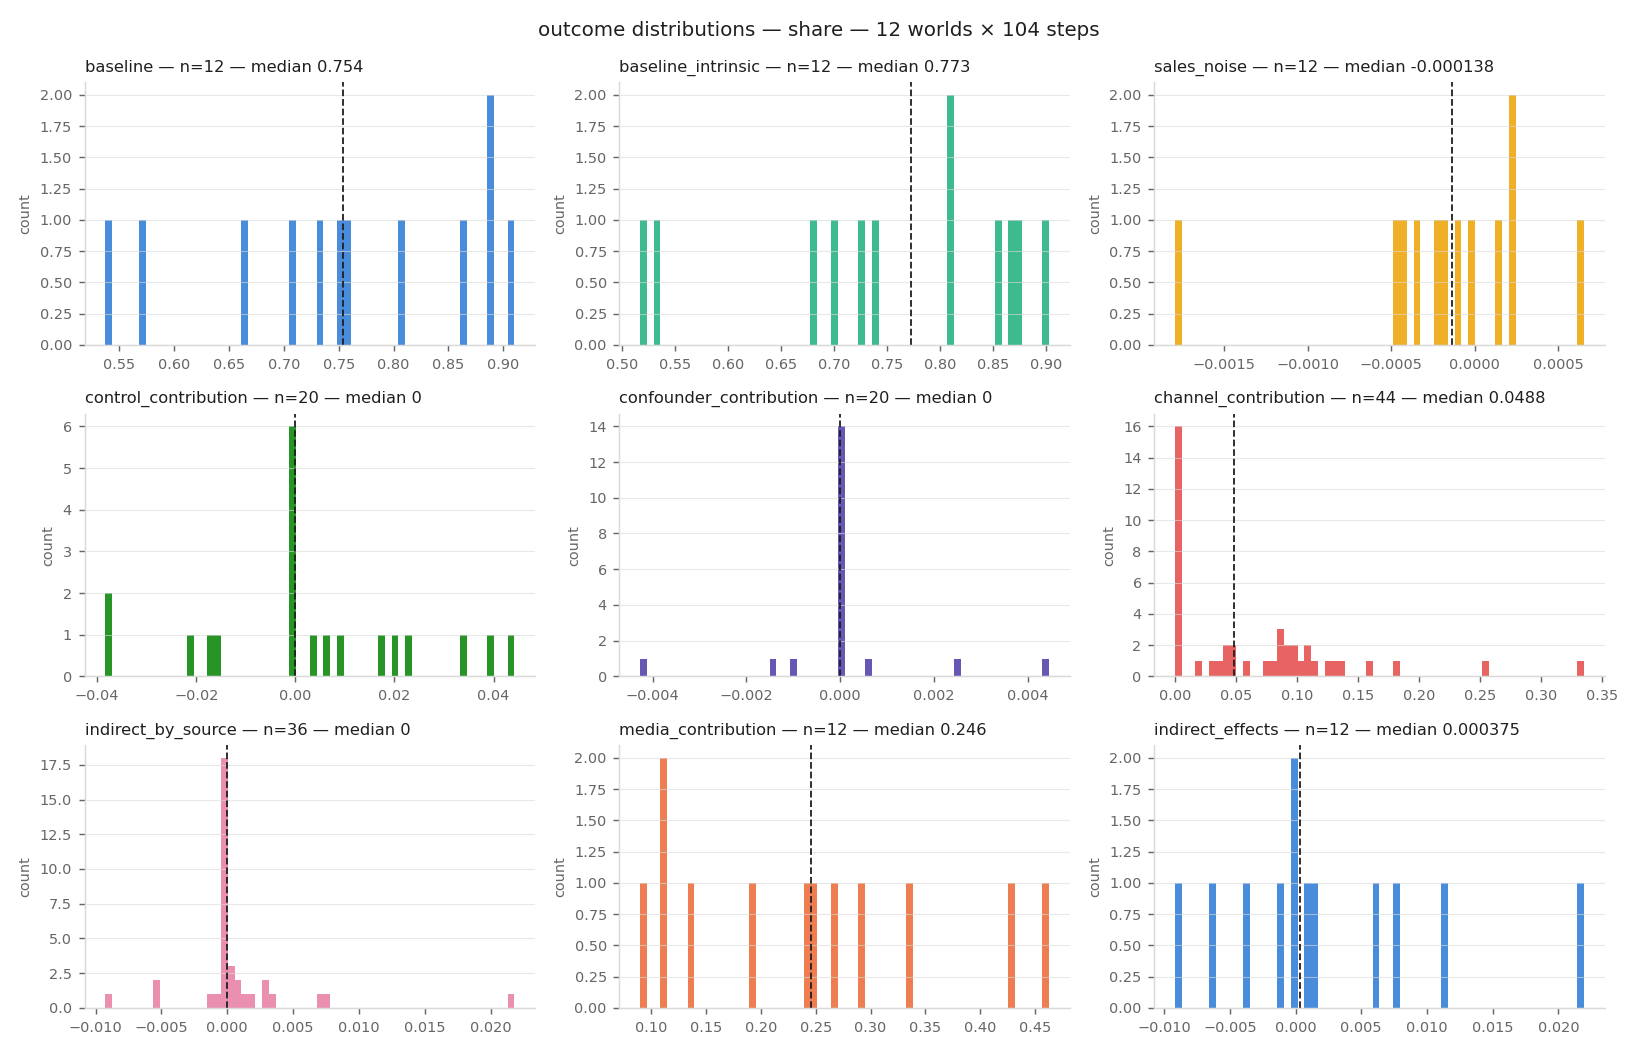

In [29]:
fig_path = os.path.join(tempfile.mkdtemp(), 'outcomes.png')
viz.plot_outcome_distributions(dist, fig_path, of='share')
display(Image(filename=fig_path))

`dist.summary()` is JSON-ready for a report, and `dist.to_frame()` is a
long-form pandas table with one row per unit.

In [30]:
frame = dist.to_frame()
print(frame.groupby('quantity')[['mean', 'std', 'share']]
      .median(numeric_only=True).round(4).to_string())

                           mean     std   share
quantity                                       
baseline                 4.7114  0.3287  0.7541
baseline_intrinsic       4.7553  0.0209  0.7726
channel_contribution     0.4364  0.0828  0.0488
confounder_contribution  0.0000  0.0000  0.0000
control_contribution     0.0000  0.1844  0.0000
controls                 0.0687  0.9280     NaN
demand                   0.0399  0.6988     NaN
indirect_by_source       0.0000  0.0036  0.0000
indirect_effects         0.0023  0.0561  0.0004
media_contribution       1.4661  0.2267  0.2459
sales                    6.6748  0.6104  1.0000
sales_noise             -0.0010  0.0343 -0.0001
spend                    3.1685  1.4931     NaN


## 11 · Persist a corpus and an auditable bundle

`save_corpus` / `load_corpus` round-trip a compressed `.npz` that needs only
numpy to read. `write_scm_bundle` writes one world as a human-auditable
folder: CSVs, the graph, the equations, and the realised parameters.

In [31]:
root = tempfile.mkdtemp()
npz = os.path.join(root, 'corpus.npz')
pg.save_corpus(corpus, npz)
loaded = pg.load_corpus(npz)
print('corpus round-trips exactly:',
      bool(np.array_equal(corpus['spend_raw'], loaded['spend_raw'])))

bundle = pg.write_scm_bundle(confounded, os.path.join(root, 'world'))
print('bundle files:', sorted(os.listdir(bundle)))

corpus round-trips exactly: True


bundle files: ['channels.png', 'dag.dot', 'dag.png', 'dataset.csv', 'decomposition.png', 'description.txt', 'timeseries.png', 'true_components.csv', 'true_contribution.csv']


## Recap

You went from a one-arrow graph to a confounded five-channel corpus, one
parameter group at a time:

1. `edge_budget` places the arrows; the three sizes pin the layout.
2. Observables are `channels`, `controls`, `sales`. Everything else is truth.
3. The decomposition is exact — `identity_error()` proves it per world.
4. Media response is `beta · saturation(adstock(spend))`, κ-relative.
5. Channel texture is what makes the response *identifiable*.
6. `rw_baseline_std_range` / `rw_sales_std_range` set the residual/media
   ratio — the axis that decides whether any model can recover a world.
7. `zc` and `cc` add observed confounding and channel interaction.
8. `dc` + `dy` (or `confounding_strength_range`) break causal sufficiency.
9. `outcome_distributions` reads the corpus in outcome space: how large Y
   gets, and what share of it each cause accounts for.

Next: [MMM recovery case study](simple-model.ipynb) fits a real MMM to one
of these worlds, shows where it fails, and compares it against the posterior
oracle. The [API reference](../reference/index.md) documents every public
symbol.